---
title: Linear Algebra in Python
jupyter: python3
---


<link rel="preconnect" href="https://fonts.googleapis.com">
<link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
<link href="https://fonts.googleapis.com/css2?family=Fira+Mono&family=Fira+Sans&display=swap" rel="stylesheet">

In this chapter we will learn how to use Python for linear algebra. 

## Packages

In the first session of this crash course you have learned the basics of Python: how to use Python as a calculator, use lists, for-loops, and if-else-statements. 

Python can be used for much more advanced operations as well. As you can imagine, code quickly grows more complicated. Fortunately, we can reuse code written by other through so-called **packages**. In the optional chapter @sec-math-basics you might have seen several packages already. Using packages has several advantages. If you use a standard package, then it makes your code more readable. It also reduces the risk of errors: Python packages are typically developed by expert programmers and thoroughly tested before they are released to the public. For the mainstream packages that we will be using, you can thus be reasonably confident that they deliver what they promise. Another major advantage of packages is that they are often heavily optimized in terms of speed and memory efficiency.^[Under the hood, numpy for instance relies on BLAS and LAPACK for most of its linear algebraic subroutines. BLAS and LAPACK are written in a programming language called Fortran, see for example the <a href ="https://www.netlib.org/lapack/#_presentation">LAPACK documentation</a>. LAPACK is used by many other programming languages, including Matlab.] If `numpy` and/or `sympy` are not installed, one can install them with the commands: run "pip install sympy" and "pip install numpy".



Today we will use several well-known packages:

- <a href="https://numpy.org/">NumPy</a>, 
- Sympy, 
- and <a href="https://matplotlib.org/">Matplotlib</a>. 


In a nutshell: packages are functions written by other people to make our life easy, i.e., so that we do not have to write every code file from scratch in Python.



## Why `numpy` and `sympy`?

The package `numpy` is designed for fast numerical calculations, e.g., with matrices. We can compute matrix products, solve linear systems, and compute inverses with `numpy` very quicky.
The package `sympy`, on the other hand, is a symbolic mathematics library. It can do exact algebraic manipulations (also with variables x and y), but it is less quick than numerical computations with `numpy`. `sympy` also contains a method to do exact row-reduction, to bring a matrix into reduced echelon form. This may also be useful if you did row-reduction by hand and want to verify your result with the computer. 

## Basic matrix and vector operations with Numpy

Suppose we have the following vectors $\mathbf{x}$ and $\mathbf{y}$, and matrix $A$: 
$$
\mathbf{x}=\left[\begin{array}{c}1\\2\\3 \end{array} \right], \mathbf{y}=\left[\begin{array}{c}4\\5\\7 \end{array} \right],  A =  \begin{bmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \\ 7 & 8 & 9 \end{bmatrix}
$$
We write these vectors in Python as follows:


In [1]:
import numpy as np

# Define the vectors and matrix
x = np.array([1, 2, 3])
y = np.array([4, 5, 7])
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

In python, we can add vectors, compute the matrix-vector product and multiply matrices.
Note: To compute a matrix-vector product you use the command A@x. What happens if you use the command A*x?
Now, try to compute $A\mathbf{x}$, $A\mathbf{y}$, and $A(\mathbf{x}+\mathbf{y})$ with Python. What do you notice?

In [3]:
print(A@x)
print(A@y)
print(A@(x+y))

[14 32 50]
[ 35  83 131]
[ 49 115 181]


## Application: input-output models 

(From Python Linear Algebra Notebook by Herbert Hamers)

A chemical plant receives oil from three different regions: the Middle East, South America, and the NorthSea. The quality of the oil is different for each region. These oils will be used to produce gasoline, diesel fuel, and bike chain oil. The oil from the Middle east will be only used for the production of gasoline. Of the oil of South America, 20 % will be used for the production of gasoline, and 80 % for the production of diesel fuel. Finally, 25 % of the North Sea oil will be used to produce gasoline, 25 % to produce diesel fuel, and 50 % for the production of bike chain oil.

Suppose today a shipment arrives of 5000 barrels of oil from the Middle East, 9000 barrels of oil from South America, and 1000 barrels from the North Sea. The plant wants to know how much gasoline, diesel fuel, and bike chain oil it can produce from this shipment.

Obviously, the 5000 barrels of oil from the Middle East will completely be used for the production of gasoline, i.e. $1\cdot 5000 = 5000$ barrels of gasoline. Of the 9000 barrels of South America oil, 20 % will be used for the produc- tion of gasoline. Hence, this leads to $0.2 \cdot 9000 = 1800$ barrels of gasoline. Finally, of the 1000 barrels of North sea oil 25 % will be used for the production of gasoline. Hence, we obtain $0.25\cdot 1000 = 250 $ barrels of gasoline. Hence, the total number of barrels of gasoline that will be produced is
$$
1 \cdot 5000 + 0.2 \cdot 9000 + 0.25 \cdot 1000 = 5000+1800+250=7050.
$$
By a similar computation, one can compute the total number of barrels of diesel fuel:
$$
0 \cdot 5000 + 0.8 \cdot 9000 + 0.25 \cdot 1000 = 7450.
$$
Finally, one can show that the total number of barrels of bike chain oil is $500$, using a similar computation. 

The production process can be summarized using the matrix-vector product. The production process is represented by the following matrix:
$$
\begin{bmatrix} 1 & 0.2 & 0.25 \\ 0 & 0.8 & 0.25 \\ 0 &0 &0.5 \end{bmatrix}
$$
where the first column represents the division in the three end products of the Middle East oil, the second column represents the division in the three end products of the South America oil, and the third column represents the division in the three end products of the North Sea oil.

In [4]:
A=np.array([[1,0.2,0.25],[0,0.8,0.25],[0,0,0.5]])
print(A)

[[1.   0.2  0.25]
 [0.   0.8  0.25]
 [0.   0.   0.5 ]]


The shipment of the oil can be summarized by the following vector:
$$
q = \begin{bmatrix} 5000 \\ 9000 \\ 1000 \end{bmatrix}
$$

Using the matrix-vector product, it can easily be calculated how much gasoline, diesel fuel, and bike chain oil can be produced from this oil-delivery:
$$
Aq = \begin{bmatrix} 1 & 0.2 & 0.25 \\ 0 & 0.8 & 0.25 \\ 0 &0 &0.5 \end{bmatrix} \begin{bmatrix} 5000 \\ 9000 \\ 1000 \end{bmatrix} = \begin{bmatrix} 1 \cdot 5000 + 0.2 \cdot 9000 + 0.25 \cdot 1000 \\ 0 \cdot 5000 + 0.8 \cdot 9000 + 0.25 \cdot 1000 = 7450\\ 0 \cdot 5000 + 0 \cdot 9000 + 0.5 \cdot 1000  \end{bmatrix}  = \begin{bmatrix} 7050 \\ 7450 \\ 500 \end{bmatrix} 
$$

Hence, using the matrix-vector product we come to the same conclusion: the oil-delivery will result in 7050 barrels of gasoline, 7450 barrels of diesel fuel, and 500 barrels of bike chain oil.

The next day a shipment of 10000 barrels of oil from the Middle East, 1000 barrels of South America, and 200 barrels of the North Sea arrives. Determine the output of gasoline, diesel fuel, and key chain oil of this oil-delivery.

In [5]:
# Your code here
q= np.array([10000,1000,200])
A@q

array([10250.,   850.,   100.])

**Part 2** Now a chemical plant receives oil from five different regions: the Middle East, South America, the North Sea,Africa and Asia. Again, the quality of the oil is different for each region. These oils will be used to produce gasoline, diesel fuel, bike chain oil, fuel 95 and fuel 98. The oil from the Middle east will be only used for the production of gasoline. Of the oil of South America, 20 % will be used for the production of gasoline, and 80% for the production of diesel fuel. 25 % of the North Sea oil will be used to produce gasoline, 25 % to produce diesel fuel, and 50 % for the production of bike chain oil. Of the oil of Africa, 10 % will be used for the production of gasoline, 10 % for the production of bike chain oil, 30 % for the production of fuel 95 and 50% for the production of fuel 98. Finally, 30 % of the Asia oil will be used to produce gasoline, 5 % to produce diesel fuel, 50 % for the production of fuel 95, and 15% for the production of fuel 98.

Suppose today a shipment arrives of 5000 barrels of oil from the Middle East, 9000 barrels of oil from South America, 1000 barrels from the North Sea, 4000 barrels of oil from Africa, and 4000 barrels of oil from Asia. The plant wants to know how much gasoline, diesel fuel, bike chain oil, fuel 95, and fuel 98 it can produce from this shipment.

With the new information $A$ will be a 5x5 matrix and $q$ will be a 5x1 vector. Determine the output of gasoline, diesel fuel, bike chain oil, fuel 95, and fuel 98 of this oil-delivery.

In [6]:
# Your code here
A=np.array([[1,0,0,0,0],[0.2,0.8,0,0,0],[0.25,0.25,0.5,0,0],[0.1,0,0.1,0.3,0.5],[0.3,0.05,0,0.5,0.15]])
q=np.array([5000,9000,1000,4000,4000])
A@q

array([5000., 8200., 4000., 3800., 4550.])

## Matrix operations: inverse, determinant, solving linear systems


In [7]:
import numpy as np

**Exercise:**

i) Compute the determinant of the following matrices 

$$
A = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}, \qquad B = \begin{pmatrix} 1 & 2 & 3 \\ 2 & 3 & 4 \\ 1 & 1 & 1 \end{pmatrix}, \qquad C = \begin{pmatrix} 1 & 3 & 2 \\ 2 & 3 & 7 \\ 1 & 3 & 1 \end{pmatrix}
$$

ii) Prove without explicit calculation that $\det(B) = 0$

iii) Which of the matrices $A$, $B$, $C$ are invertible? For each of these matrices, compute the inverse using python.

To verify your computation of $\det(C)$ we will use Numpy. The module np.linalg contains several standard linear algebra methods that we will encounter today:
- `det`: matrix determinant
- `inv`: matrix inverse
- `solve`: solves a linear system $A x =b$

In [8]:
#For the matrix C:
C = np.array([[1, 3, 2],[2, 3, 7], [1,3,1]]) #Define C
print(C)

print("The determinant of C is", np.linalg.det(C))
print("The inverse of C is", np.linalg.inv(C))

#The matrix B has determinant zero, as the second row is equal to the first row + the last row. So it is not invertible. 
#The python commands for the matrix A are similar as for the matrix C. 

[[1 3 2]
 [2 3 7]
 [1 3 1]]
The determinant of C is 2.9999999999999996
The inverse of C is [[-6.          1.          5.        ]
 [ 1.66666667 -0.33333333 -1.        ]
 [ 1.         -0.         -1.        ]]


**Exercise**:

In the Linear Algebra course we have seen that if we multiply a single row by a constant $k$, then the determinant gets multiplied by $k$ as well. 

i) Verify this (using Python) for the matrix obtained from $C$ by multiplying the first row by $10$:
$$
D = \begin{pmatrix} 10 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1\end{pmatrix} C
$$

ii) What is $\det(10 C)$?

In [9]:
# First define the 3-by-3 matrix M for which D=MC
M = np.array([[10,0,0],[0,1,0],[0,0,1]])
# Then define D via a matrix product
D = M @ C
print(D)

#And compute its determinant:
print("The determinant of D is", np.linalg.det(D))

[[10 30 20]
 [ 2  3  7]
 [ 1  3  1]]
The determinant of D is 30.000000000000014


We can use python to solve linear systems of equations using `numpy`. Consider for example the following system of equations:

$$
\left\{\begin{array}{l}
x_1 - 3x_2  = 5 \\
-x_1 +x_2 +5x_3 = 2 \\
x_2 + x_3 = 0 
\end{array}\right.
$$

We can solve the system very efficiently numerically with the command numpy.linalg.solve:

In [10]:
import numpy as np

# Coefficient matrix A
A = np.array([[1, -3, 0],
              [-1, 1, 5],
              [0, 1, 1]])

# Right-hand side vector b
b = np.array([5, 2, 0])

# Solve the system
x = np.linalg.solve(A, b)
print("Solution:", x)

Solution: [ 2. -1.  1.]


As you can see, the solution is x_1=2.0, x_2=-1.0, x_3=1.0. Note that the output is _numerical_ i.e., it is an approximation computed with finite precision arithmetic inside the computer. `numpy` is faster for large systems than `sympy`, but it may introduce tiny rounding errors (e.g., 2.00000000001 ipv 2).

**Exercise** use `numpy` to solve the system from Exercise 1.1.12 from the book (Lay et al):

$$
\left\{\begin{array}{l}
x_1 - 3x_2 + 4x_3 = -4 \\
3x_1 -7x_2 +7x_3 = -8 \\
-4x_1 + 6x_2 + 2x_3 = 4 
\end{array} \right.
$$

In [11]:
# your code here

# Coefficient matrix A
A = np.array([[1, -3, 4],
              [3, -7, 7],
              [-4, 6, 2]])

# Right-hand side vector b
b = np.array([-4, -8, 4])

# Solve the system
x = np.linalg.solve(A, b)
print("Solution:", x)

Solution: [2.00000000e+00 2.00000000e+00 1.85037171e-16]


## Modifying matrix entries

Consider the following large matrix A, and a zero matrix B of the same size as A:

In [12]:
A = np.array([
    [5, 12, 7, 3, 14, 6, 9, 2, 11, 8],
    [1, 13, 4, 10, 7, 5, 12, 6, 8, 3],
    [9, 2, 11, 5, 13, 7, 4, 10, 6, 12],
    [8, 1, 14, 6, 9, 3, 11, 2, 5, 13],
    [7, 10, 3, 12, 6, 9, 2, 8, 4, 11],
    [2, 6, 9, 5, 11, 7, 3, 12, 10, 1],
    [4, 8, 2, 10, 5, 13, 6, 9, 1, 7],
    [12, 3, 6, 11, 2, 8, 5, 14, 7, 10],
    [10, 5, 1, 7, 12, 4, 8, 3, 6, 9],
    [3, 9, 5, 8, 1, 10, 7, 11, 2, 12]
])
B=np.zeros((10,10))

We can modify entries of B separately. E.g., we can modify the top-left entry of B to be 100:

In [13]:
B[0,0]=100
print(B)

[[100.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]]


**Exercise:** Use for loops over the row indices i and column indices j to modify the entries of B as follows, for each entry of A: if A_{ij} < 6:  B_{ij} =100. If A_{ij} >= 6: B_{ij} = A_{ij}. 
Then, compute the sum of all entries in B with np.sum(B). What is the result?

In [14]:
# your code here

for i in range(10):
    for j in range(10):
        if A[i, j] < 6:
            B[i, j] = 100
        elif A[i, j] >= 6:
            B[i, j] = A[i, j]

result = np.sum(B)
print(result)

4200.0


## Linear transformations of images
 
We use the `cv2` library, the `numpy` library, and the `matplotlib` library. If you do not have these libraries, go to powershell (on windows) and type the commands "pip install opencv-python"  "pip install numpy" "pip install matplotlib". Now you are ready to go!

In [15]:

import cv2
import numpy as np
import matplotlib.pyplot as plt 



A linear transformation for a vector in $\mathbb{R}^2$ can be represented by 
$$
 \begin{bmatrix}x'\\ y' \end{bmatrix}= \begin{bmatrix}a_{11}& a_{12} \\ a_{21}& a_{22} \\ \end{bmatrix}\begin{bmatrix}x\\ y\end{bmatrix}
$$

For images, $(x,y)$ are the pixel coordinates  of the original image and $(x',y')$ are the pixel coordinates of the transformed image. First we load in an image (this can be any image with the name `image.jpg', but it must be in the same folder as the python notebook):

(-0.5, 1023.5, 767.5, -0.5)

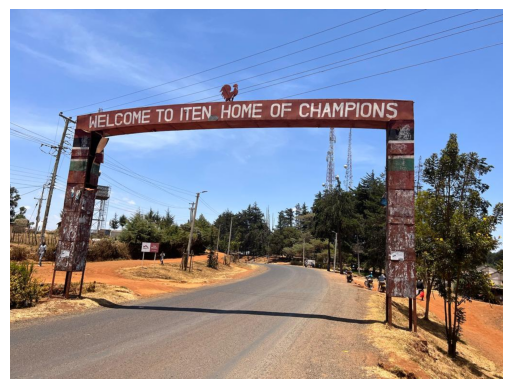

In [16]:
img2 = cv2.imread('image.jpg')

plt.imshow(img2[:,:,::-1])
plt.axis('off')

The picture can be seen as a set of points in $\mathbb{R}^2$, corresponding to the pixels, where each point is assigned a color. 
We are now going to move the points according to a linear transformation $\mathbb{R}^2 \to \mathbb{R}^2$ which maps $\mathbf{x}$ to $A\textbf{x}$.

We first predefine a python command to apply a transformation to the image.

In [17]:
# function to apply transformation and visualize the result (source: kaggle.com)
def perform_Transformation(image, A):
    """
    Takes in input image and the transformation matrix 
    Appl
    """
    rows,cols,ch = image.shape

    M = np.array([[A[0,0], A[0,1], 0],
                [A[1,0], A[1,1], 0]])

    dst = cv2.warpAffine(image,M,(cols,rows))
    
    
    plt.figure(figsize = (24,8))
    plt.subplot(211); plt.imshow(image[:,:,::-1]); plt.title('Original Image')
    
    plt.subplot(212); plt.imshow(dst[:,:,::-1]); plt.title("Transformed Image")

Next, we enter a 2x2 matrix, using python's `numpy` library.

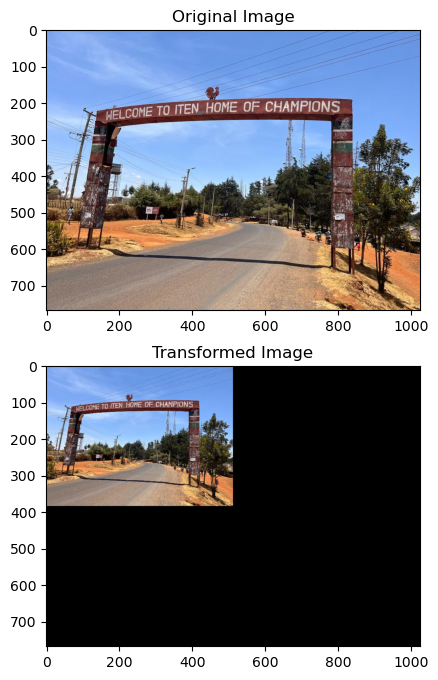

In [18]:
A = np.array([[0.5,0],
                [0,0.5]])

#scales the picture down 50% in both the x direction and y direction

perform_Transformation(img2, A)

**Exercise** 

a) Can you scale the picture 50% down in the $x$-direction only? 

b) Investigate what the matrix $A=\begin{bmatrix} 0  &1 \\ 1 & 0  \end{bmatrix}$ does to the picture. What does it do? Can you explain why?

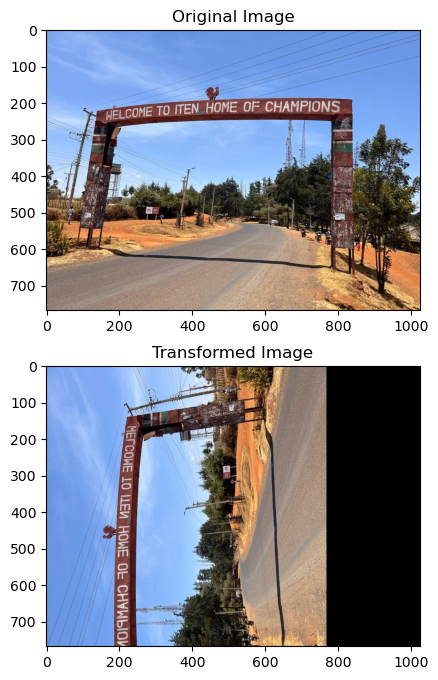

In [19]:
# your code here

A = np.array([[0,1.0],
                [1,0]])

#swaps x and y

perform_Transformation(img2, A)

The following matrix rotates the picture approximately 45 degrees (sadly, the image is only partly visible then): 

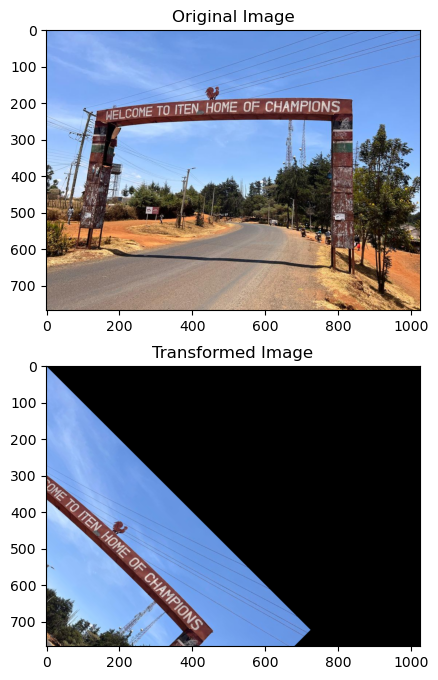

In [20]:
A = np.array([[0.707,-0.707],
                [0.707,0.707]])

perform_Transformation(img2, A)

**Exercise** 

a) Let $A=\begin{bmatrix} 0.5  &0 \\ 0 & 1  \end{bmatrix}$ and $B= \begin{bmatrix} 0  &1 \\ 1 & 0  \end{bmatrix}$. What is $AB$? What is $BA$? Hint: compute the product $AB$ with python using A@B.

b) Investigate what the matrix $\begin{bmatrix} 0  &1 \\ 1 & 0  \end{bmatrix}*\begin{bmatrix} 0.5  &0 \\ 0 & 1  \end{bmatrix}$ does to the picture. What does it do? Can you explain why?

c) What does the matrix $\begin{bmatrix} 0.5  &0 \\ 0 & 1  \end{bmatrix} *\begin{bmatrix} 0  &1 \\ 1 & 0  \end{bmatrix}$  to the picture and why? 

d) Can you scale the picture 50% down in the $x$-direction only, and then rotate the picture (approximately) 45 degrees? (What matrix corresponds to this?)

[[0.  0.5]
 [1.  0. ]]
[[0.  1. ]
 [0.5 0. ]]


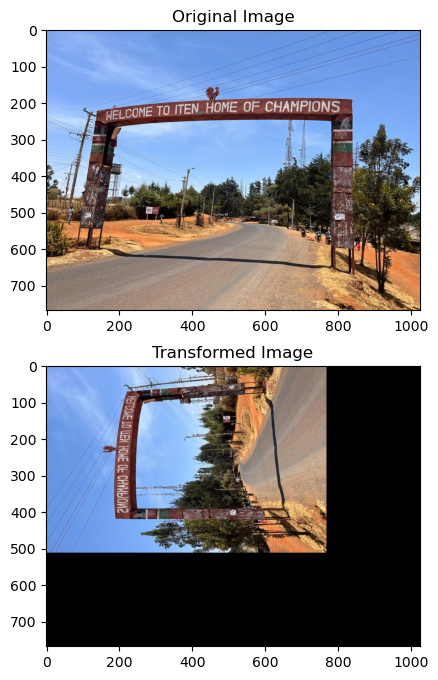

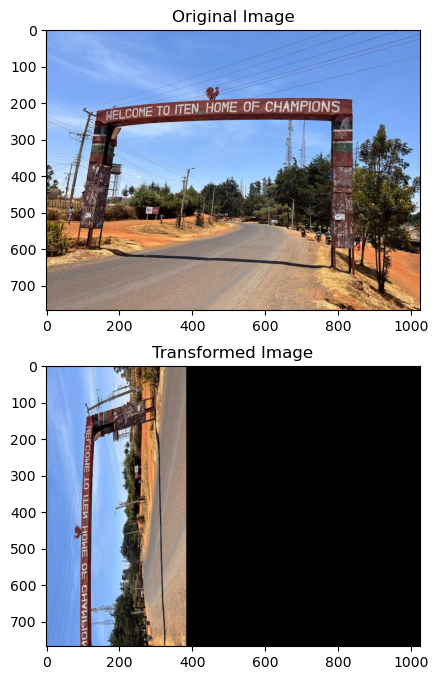

In [21]:
# your code here

A = np.array([[0.5, 0],
                [0, 1]])

B = np.array([[0, 1],
             [1, 0]])

print(A @ B)

print(B @ A)

perform_Transformation(img2, B @ A)

perform_Transformation(img2, A @ B)

## Symbolic computations: sympy


The `sympy` library is for symbolic computations. We will now demonstrate how this library works. `sympy` also contains a function to bring a matrix into reduced echelon form. This is very useful if you want to verify manual calculations. 

In [22]:
import sympy as sp

We now show how to solve Exercise 1.1.12 from the book (Lay et al) using Python. Solve the system of equations:

$$
\left\{\begin{array}{l}
x_1 - 3x_2 + 4x_3 = -4 \\
3x_1 -7x_2 +7x_3 = -8 \\
-4x_1 + 6x_2 + 2x_3 = 4 
\end{array}\right.
$$
 The augmented matrix of the system of linear equations is

$$
\left[\begin{array}{ccc|c}
1 & -3 & 4 & -4 \\
3 & -7 & 7 & -8 \\
-4 & 6 & 2 & 4 \\
\end{array}\right]
$$

In Python with `sympy`:

In [23]:
Ab=sp.Matrix([[1,-3,4,-4],[3,-7,7,-8],[-4,6,2,4]])

Now we can find the reduced form of the system using rref() from the sympy library. The method returns two elements. The first is the row-reduced echelon form of the matrix, and the second is a list of the pivot columns. By typing Ab_rref[0], only the row-reduced echelon form is printed.

In [24]:
Ab_rref = Ab.rref()
Ab_rref[0]

Matrix([
[1, 0, 0, 2],
[0, 1, 0, 2],
[0, 0, 1, 0]])

The system is consistent and we can immediately see the general solution: $x_1=2$, $x_2=2$ and $x_3=0$. The solution is exact, e.g., Python did not round the number 2 to 2.00000 as it does when using the `numpy` module. `sympy` allows us to do exact computation with matrices, as opposed to approximate computations with `numpy`. Computations with `sympy` are generally slower than with `numpy`, so for very large systems, `numpy` is preferred.

**Exercise** Use python to solve the following system of equations:

$$
\left\{\begin{array}{l}
x_1 - 3x_2  = 5 \\
-x_1 +x_2 +5x_3 = 2 \\
x_2 + x_3 = 0 
\end{array}\right.
$$

In [25]:
Ab=sp.Matrix([[1,-3,0,5],[-1,1,5,2],[0,1,1,0]])
Ab_rref = Ab.rref()
Ab_rref[0]

Matrix([
[1, 0, 0,  2],
[0, 1, 0, -1],
[0, 0, 1,  1]])

## Application: supply and demand model
(From Linear Algebra notebook by Herbert Hamers)

The demand $q_d$ and supply $q_s$ of an item depend on the price $p$ and income $Y$. Suppose that the relation between demand, price and income can be described by the equation

$$q_d = 8 - 0.2p + 0.1Y,$$

and the relation between supply and price by the equation

$$q_s = 6 + 0.3p.$$

The market is in equilibrium if $q_s = q_d$. Replacing both $q_s$ and $q_d$ by the new variable $q$, the market equilibrium can be found by solving the following system of two linear equations for the unknowns $p$, $q$ and $Y$:

$$
\left\{\begin{array}{l}
q = 8 - 0.2p + 0.1Y\\
q = 6 + 0.3p.
\end{array}\right.
$$

First, we will rewrite this system of linear equations. We place all terms with a variable to the left of the equal sign and moreover we put terms with the same variable in the different equations right below each other:

$$
\left\{\begin{array}{l}
q + 0.2p - 0.1Y = 8\\
q - 0.3p = 6.
\end{array}\right.
$$

In [26]:
Ab = sp.Matrix([[1, 0.2, -0.1, 8], [1, -0.3, 0, 6]]) 
Ab

Matrix([
[1,  0.2, -0.1, 8],
[1, -0.3,    0, 6]])

**Exercise** 

How many solutions does this system of linear equations have? You can use the function rref() again to find the row reduced echelon form of the above matrix. 
Determine the solution if $Y=50$.

In [27]:
Ab_rref = Ab.rref()
Ab_rref[0]

Matrix([
[1, 0, -0.06, 7.2],
[0, 1,  -0.2, 4.0]])

In [28]:
#The system has infinitely many solutions. (It is consistent, and has no pivot in the column corresponding to Y.)
#q=7.2+0.06*50=10.2
#p=4.0+0.2*50=14

## Symbolic computation of the determinant in Python with `sympy`

The `sympy` package can also be used to calculate determinants of symbolic matrices.

**Exercise**:
 
We now investigate how to compute determinants of _symbolic_ matrices using sympy. Let $A = \begin{pmatrix}  1 & 0 & x \\ 1 & -x & 0 \\ x & 0 & -x \end{pmatrix}$. Compute $\det(A)$ using the `sympy` module. 

In [29]:
import sympy as sp

In [30]:
x = sp.symbols('x')
A = sp.Matrix([[1,0,x],[1,-x,0],[x,0,-x]])
A

Matrix([
[1,  0,  x],
[1, -x,  0],
[x,  0, -x]])

In [31]:
print("The determinant of A is: \n")
A.det()

The determinant of A is: 



x**3 + x**2

To be able to see more easily for which values of $x$ the determinant equals $0$ we can use `sympy`'s factor function:

In [32]:
print("The determinant of A is: \n")
sp.factor(A.det())

The determinant of A is: 



x**2*(x + 1)

For which values of $x$ is $A$ invertible?

A is invertible if x is not equal to 0 and not equal to -1.
